In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Cargamos el dataset modelable a 10 segundos

df = pd.read_csv("data_limpio/dataset_modelable_10s.csv")

df["Time"] = pd.to_datetime(df["Time"])

df.head()

,Time,LT411,SP_LT411,LV411,DT412,INT_P101,FQC400_1,SP_VAPOR,FV400_1,PT442,SP_PT442,PV442,TT413,TT415,LT426,SP_LT426,ACCION_PCT02,FT428,PIT410,PIT414
0,2021-11-05 08:00:00,58.142360,60.0,100.0,1229.492151,58.408563,3054.785938,69.0,59.5,0.154167,0.14,0.0,80.976565,81.82292,50.439814,50.0,18.861438,6.266928,0.326085,0.579514
1,2021-11-05 08:00:10,57.962962,60.0,100.0,1229.049451,58.272569,3052.526001,69.0,59.5,0.154282,0.14,0.0,80.954863,81.81424,50.422452,50.0,19.102801,6.293403,0.326181,0.579456
2,2021-11-05 08:00:20,57.323494,60.0,100.0,1229.088501,58.234953,3038.494727,69.0,59.5,0.154225,0.14,0.0,80.946182,81.81424,50.434027,50.0,19.315793,6.325521,0.326403,0.579051
3,2021-11-05 08:00:30,57.335069,60.0,100.0,1228.762976,58.463541,3031.794189,69.0,59.5,0.154282,0.14,0.0,80.946182,81.81424,50.422452,50.0,19.470506,6.357205,0.326340,0.578588
4,2021-11-05 08:00:40,57.835647,60.0,100.0,1229.453088,58.159721,3036.406226,69.0,59.5,0.154485,0.14,0.0,80.946182,81.81424,50.428239,50.0,19.712129,6.391927,0.326403,0.578125


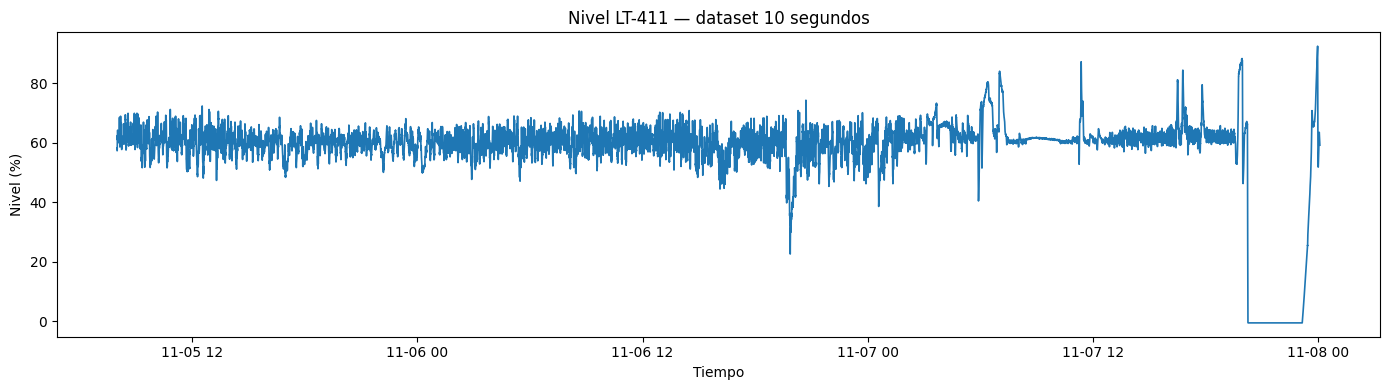

In [4]:
plt.figure(figsize=(14, 4))
plt.plot(df["Time"], df["LT411"], linewidth=1.2)

plt.title("Nivel LT-411 — dataset 10 segundos")
plt.xlabel("Tiempo")
plt.ylabel("Nivel (%)")
plt.tight_layout()
plt.show()

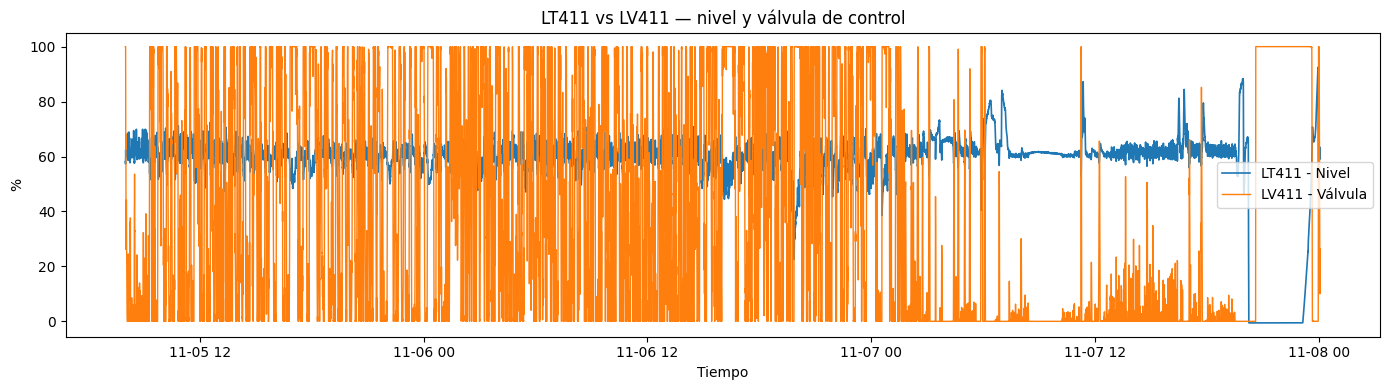

In [5]:
plt.figure(figsize=(14, 4))

plt.plot(df["Time"], df["LT411"], linewidth=1.2, label="LT411 - Nivel")
plt.plot(df["Time"], df["LV411"], linewidth=1.0, label="LV411 - Válvula")

plt.title("LT411 vs LV411 — nivel y válvula de control")
plt.xlabel("Tiempo")
plt.ylabel("%")
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# Creamos una columna con la fecha para separar los días

df["fecha"] = df["Time"].dt.date

df["fecha"].value_counts().sort_index()

fecha
2021-11-05    5760
2021-11-06    8640
2021-11-07    8640
2021-11-08      30
Name: count, dtype: int64

In [8]:
# Definimos cortes temporales iniciales para train, validación y test

inicio_train = pd.Timestamp("2021-11-05 08:00:00")
fin_train = pd.Timestamp("2021-11-06 07:59:59")

inicio_valid = pd.Timestamp("2021-11-06 08:00:00")
fin_valid = pd.Timestamp("2021-11-07 07:59:59")

inicio_test = pd.Timestamp("2021-11-07 08:00:00")
fin_test = df["Time"].max()

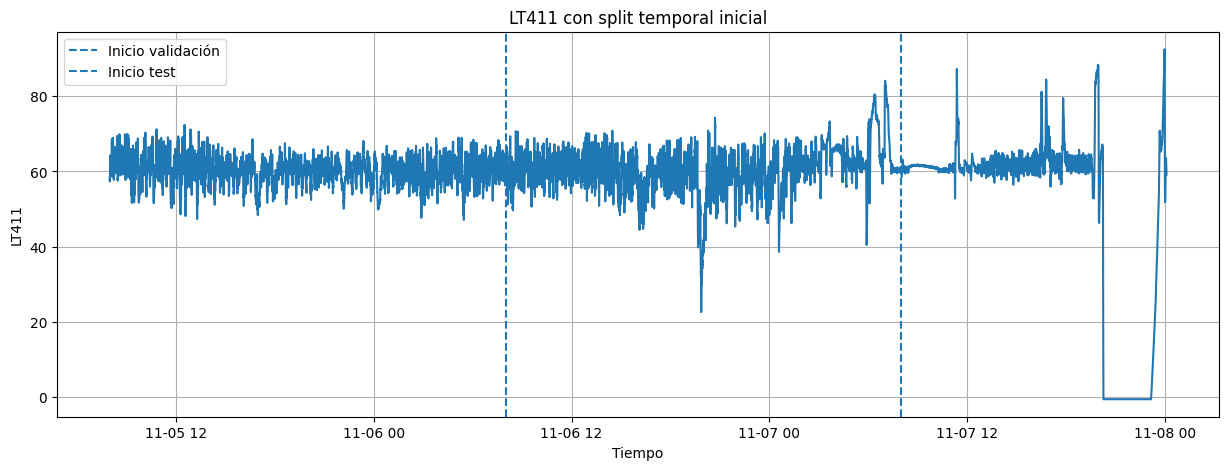

In [10]:
# Graficamos LT411 marcando train, validación y test

plt.figure(figsize=(15, 5))
plt.plot(df["Time"], df["LT411"])

plt.axvline(inicio_valid, linestyle="--", label="Inicio validación")
plt.axvline(inicio_test, linestyle="--", label="Inicio test")

plt.title("LT411 con split temporal inicial")
plt.xlabel("Tiempo")
plt.ylabel("LT411")
plt.grid(True)
plt.legend()
plt.show()

In [11]:
# Asignamos cada fila a train, validación o test

df["bloque"] = "sin_asignar"

df.loc[(df["Time"] >= inicio_train) & (df["Time"] <= fin_train), "bloque"] = "train"
df.loc[(df["Time"] >= inicio_valid) & (df["Time"] <= fin_valid), "bloque"] = "validacion"
df.loc[(df["Time"] >= inicio_test) & (df["Time"] <= fin_test), "bloque"] = "test"

df["bloque"].value_counts()

bloque
train         8640
validacion    8640
test          5790
Name: count, dtype: int64

In [12]:
# Revisamos inicio, fin y número de filas por bloque

df.groupby("bloque").agg(
    inicio=("Time", "min"),
    fin=("Time", "max"),
    filas=("Time", "count")
)

,inicio,fin,filas
bloque,,,
test,2021-11-07 08:00:00,2021-11-08 00:04:50,5790
train,2021-11-05 08:00:00,2021-11-06 07:59:50,8640
validacion,2021-11-06 08:00:00,2021-11-07 07:59:50,8640


In [14]:
# Revisamos estadísticas de LT411 por bloque

df.groupby("bloque")["LT411"].describe()

,count,mean,std,min,25%,50%,75%,max
bloque,,,,,,,,
test,5790.0,50.143939,25.263527,-0.578704,59.401041,61.203703,62.467447,92.491317
train,8640.0,59.809870,3.617674,47.094907,57.580294,60.128761,62.161457,72.375578
validacion,8640.0,60.305748,6.168719,22.586805,57.209200,60.692997,63.545283,84.079861


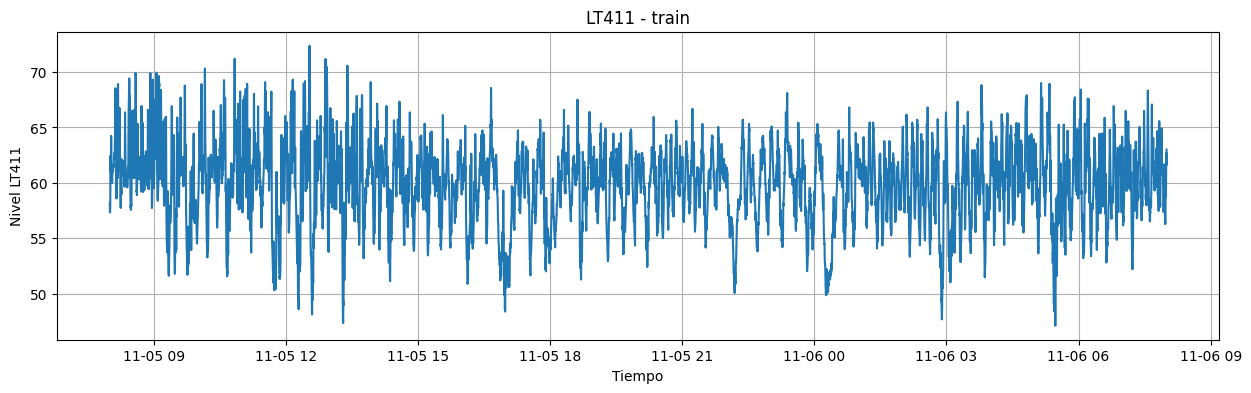

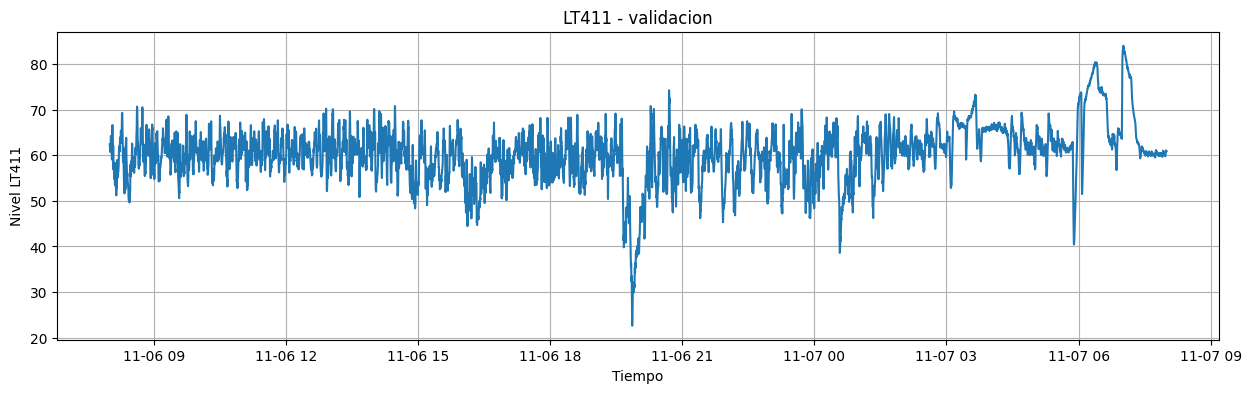

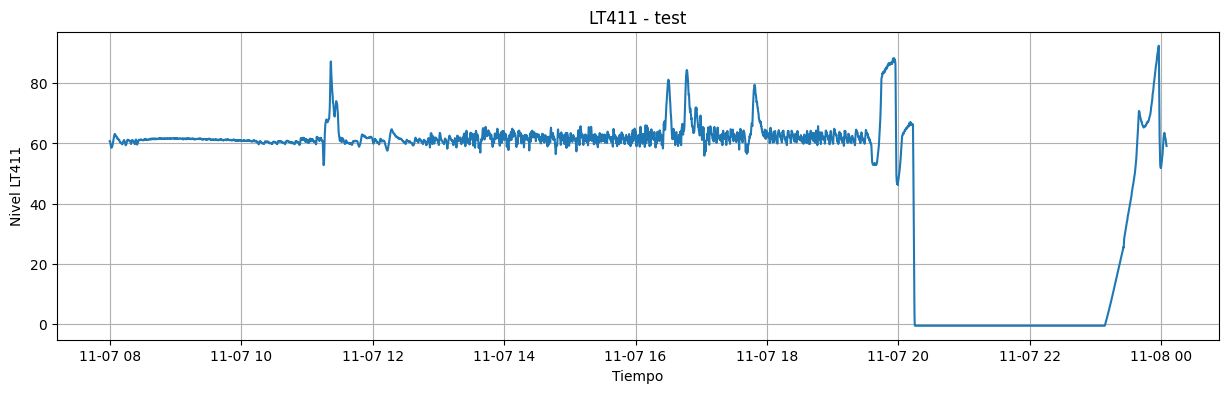

In [15]:
# Graficamos LT411 separando train, validación y test

for bloque in ["train", "validacion", "test"]:
    datos_bloque = df[df["bloque"] == bloque]

    plt.figure(figsize=(15, 4))
    plt.plot(datos_bloque["Time"], datos_bloque["LT411"])
    plt.title("LT411 - " + bloque)
    plt.xlabel("Tiempo")
    plt.ylabel("Nivel LT411")
    plt.grid(True)
    plt.show()

In [17]:
# Definimos variables principales para revisión visual

variables_revision = [
    "LT411",
    "PIT410",
    "PIT414",
    "TT413",
    "TT415",
    "DT412",
    "INT_P101",
    "FQC400_1",
    "PT442",
    "FT428",
    "LT426"
]

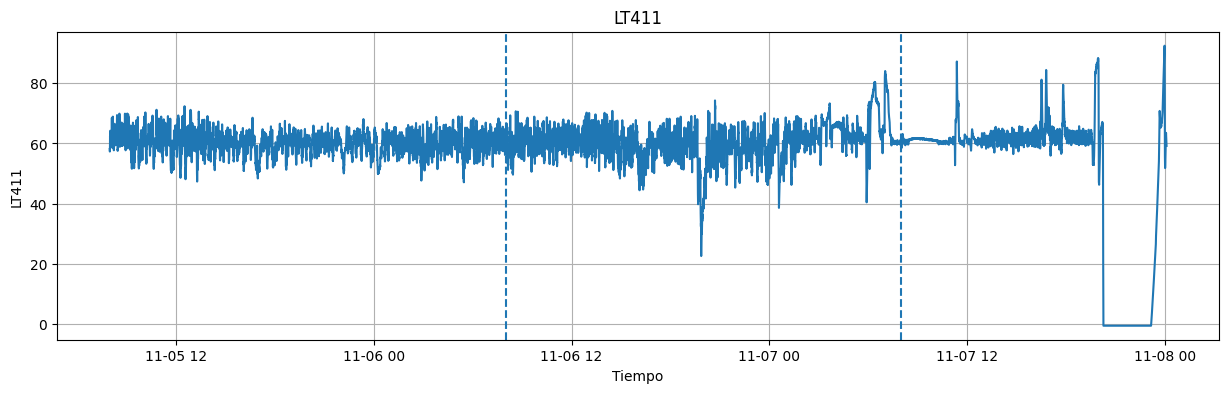

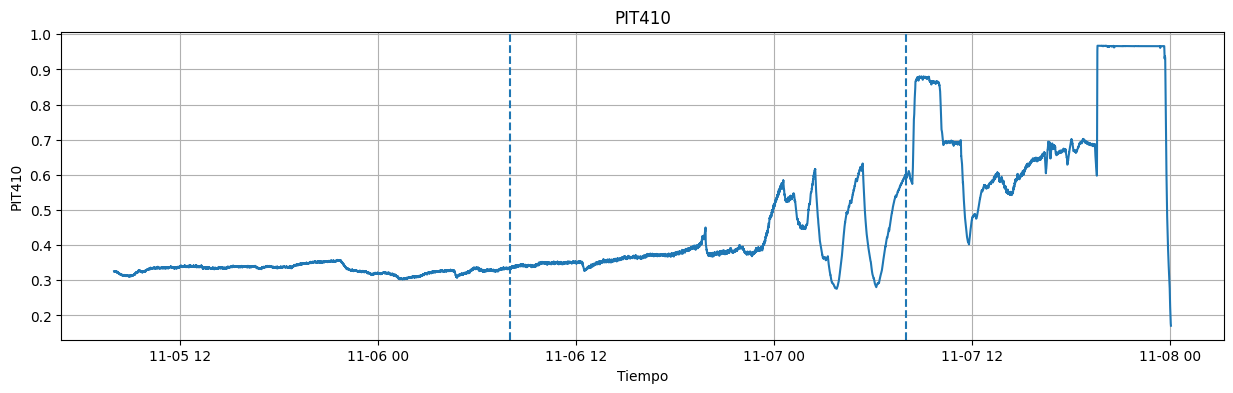

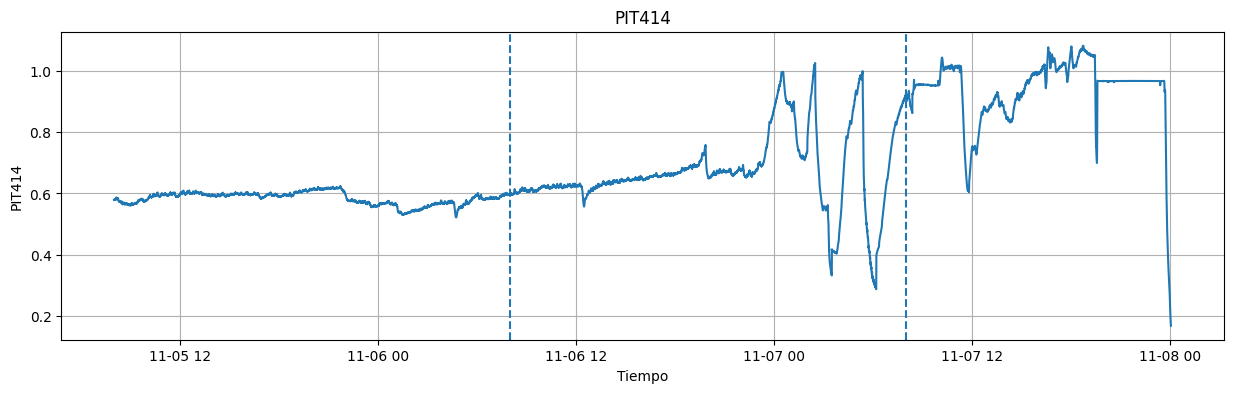

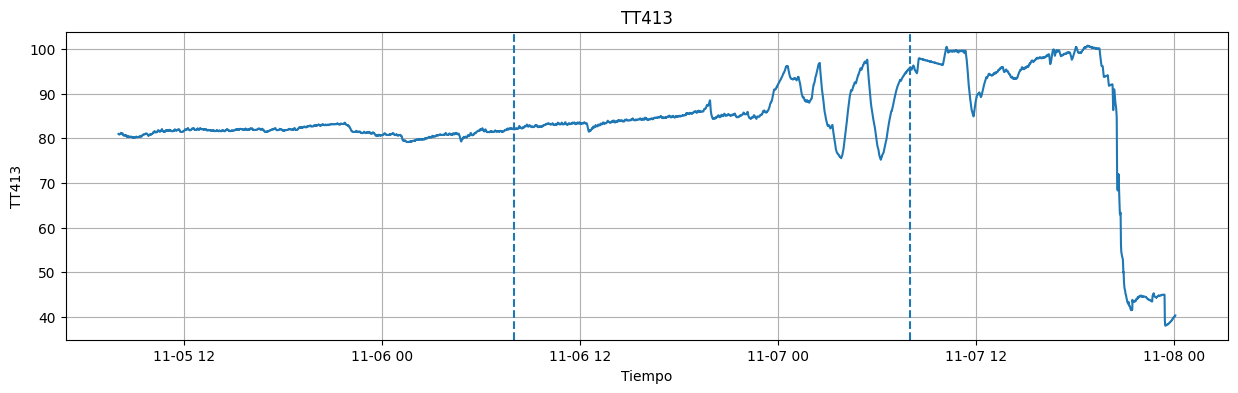

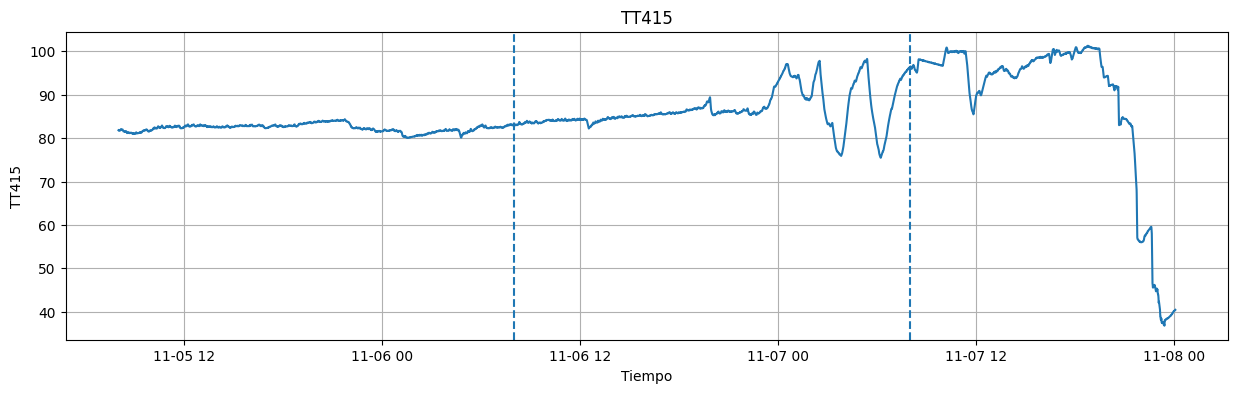

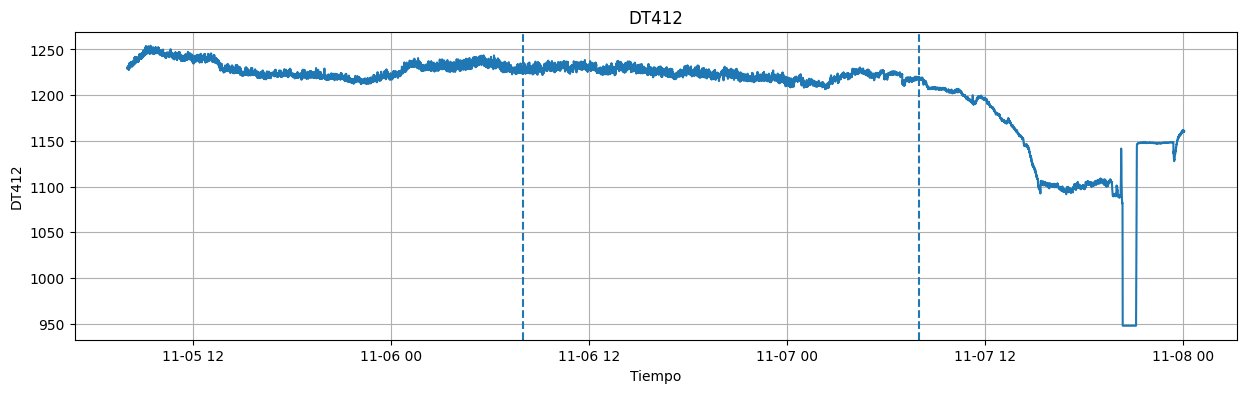

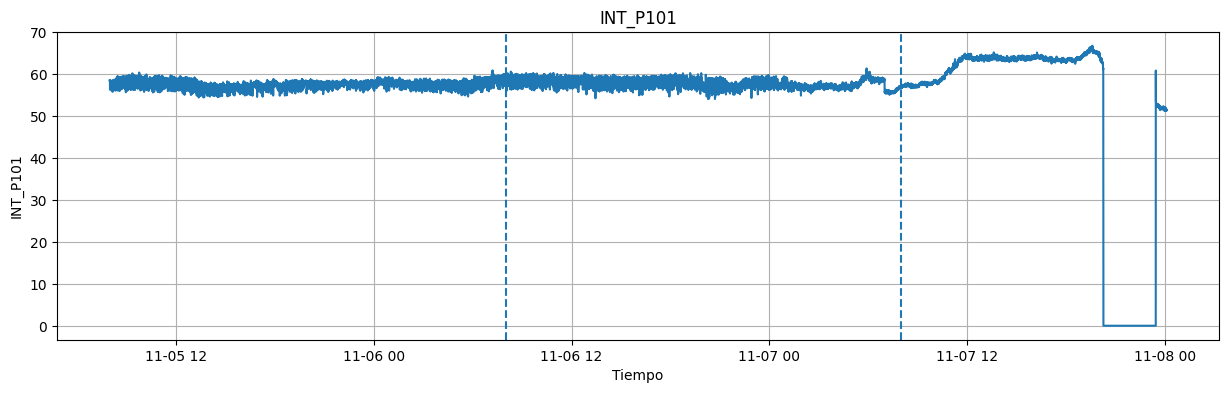

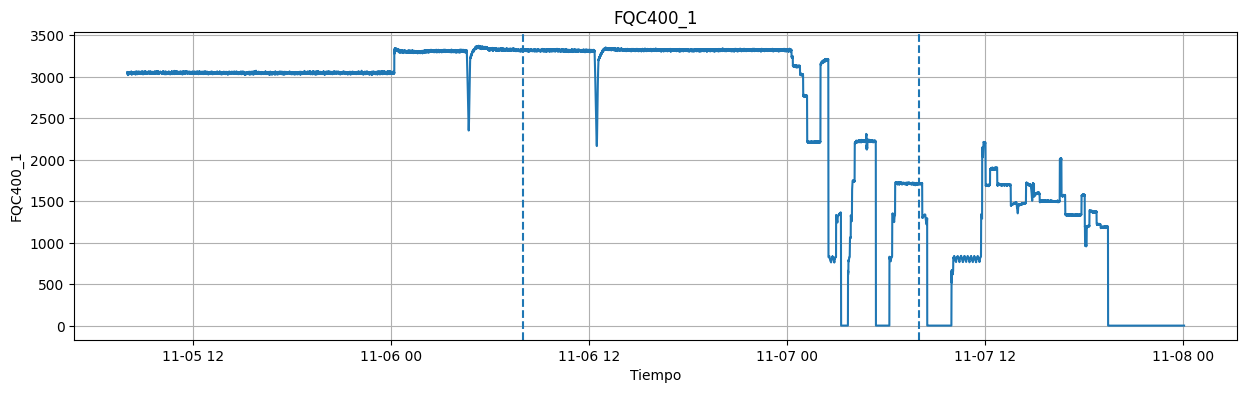

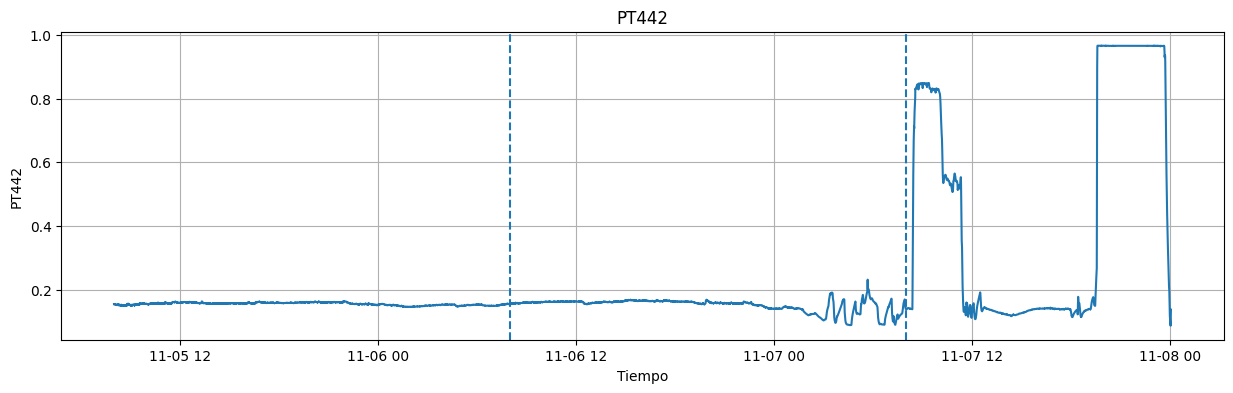

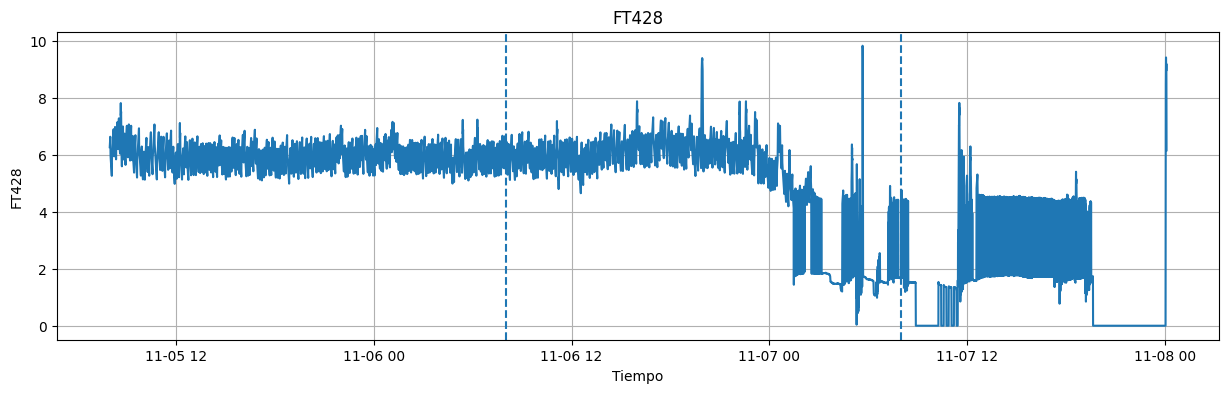

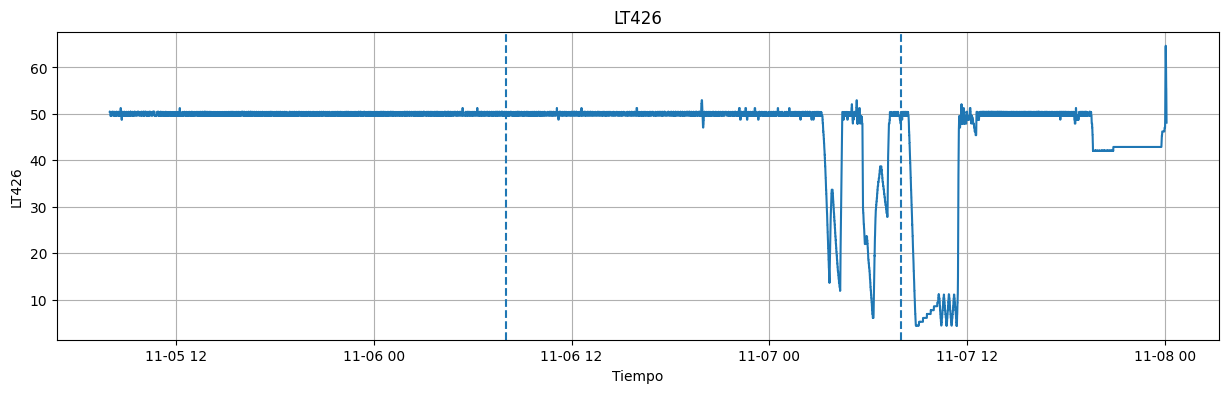

In [18]:
# Graficamos variables clave para revisar comportamiento temporal

for variable in variables_revision:
    plt.figure(figsize=(15, 4))
    plt.plot(df["Time"], df[variable])
    plt.axvline(inicio_valid, linestyle="--")
    plt.axvline(inicio_test, linestyle="--")
    plt.title(variable)
    plt.xlabel("Tiempo")
    plt.ylabel(variable)
    plt.grid(True)
    plt.show()

## Nota sobre FQC400_1

La variable FQC400_1 contiene valores negativos físicamente imposibles.

En esta fase no se corrigen ni se eliminan filas para conservar el dataset tal como está tras la limpieza inicial.

Más adelante, durante el modelado, se comparará el impacto de:
- usar FQC400_1 original;
- crear FQC400_1_corr con valores negativos corregidos a 0;
- crear un flag de valores negativos;
- entrenar modelos con y sin esta variable.

In [19]:
# Localizamos valores bajos de LT411 en test

df_test = df[df["bloque"] == "test"].copy()

df_test[df_test["LT411"] < 20][["Time", "LT411"]].head(20)

,Time,LT411
21687,2021-11-07 20:14:30,12.138310
21688,2021-11-07 20:14:40,4.470486
21689,2021-11-07 20:14:50,0.836227
21690,2021-11-07 20:15:00,-0.465856
21691,2021-11-07 20:15:10,-0.578704
21692,2021-11-07 20:15:20,-0.578704
21693,2021-11-07 20:15:30,-0.578704
21694,2021-11-07 20:15:40,-0.578704
21695,2021-11-07 20:15:50,-0.578704
21696,2021-11-07 20:16:00,-0.578704


In [20]:
# Localizamos el mínimo de LT411 en test

df_test.loc[df_test["LT411"].idxmin(), ["Time", "LT411"]]

Time     2021-11-07 20:15:10
LT411              -0.578704
Name: 21691, dtype: object